## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# utils
from utils.load_config import load_config
from utils.load_data import load_pkl

# tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

## Helper functions

In [3]:
def metrics_report(X, y, model, domain_name):
    y_pred = model.predict(X)
    bal_acc = balanced_accuracy_score(y, y_pred)
    f1_macro = f1_score(y, y_pred, average="macro")
    recall_macro = recall_score(y, y_pred, average="macro")

    cm = confusion_matrix(y, y_pred)
    specificity = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity.append(tn / (tn + fp))
    spec_macro = np.mean(specificity)
    
    return {
        "Domain": domain_name,
        "Labels": np.unique(y), 
        "Balanced_Accuracy": bal_acc,
        "F1_Macro": f1_macro,
        "Recall_Macro": recall_macro,
        "Specificity_Macro": spec_macro,
        "Confusion Matrix": cm
    }

def print_metrics(metrics):
    domain, class_names, b_acc, f1, recall, spec, cm = metrics["Domain"], metrics["Labels"], metrics["Balanced_Accuracy"], metrics["F1_Macro"], metrics["Recall_Macro"], metrics["Specificity_Macro"], metrics["Confusion Matrix"]

    # Print metrics information
    print(f"Printing metrics for Domain: {domain}")
    print(f"Balanced Accuracy: {b_acc}")
    print(f"F1 Macro: {f1}")
    print(f"Recall Macro: {recall}")
    print(f"Specificity Macro: {spec}")

    # Plot confusion metrics with labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)

    plt.title(f"Confusion Matrix — {domain}", fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

## Data loading

In [4]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [5]:
driams = load_pkl(driams_pkl)

In [6]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [7]:
meta = pd.DataFrame.from_records(list(meta))

In [8]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data[idx],
        "label": label[idx],
        "meta": meta.iloc[idx]
    }

In [9]:
species, counts = np.unique(filtered_data["DRIAMS_A"]["label"], return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 2573
Enterococcus_Faecium: 1800
Escherichia_Coli: 7381
Klebsiella_Pneumoniae: 4083
Pseudomonas_Aeruginosa: 4908
Staphylococcus_Aureus: 7065


In [10]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataB, labelB, metaB = filtered_data["DRIAMS_B"]["data"], filtered_data["DRIAMS_B"]["label"], filtered_data["DRIAMS_B"]["meta"]
dataC, labelC, metaC = filtered_data["DRIAMS_C"]["data"], filtered_data["DRIAMS_C"]["label"], filtered_data["DRIAMS_C"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

In [11]:
dataA.shape

(27810, 6000)

In [12]:
dataD.shape

(7308, 6000)

## Models

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    dataA,
    labelA,
    test_size=0.2,
    stratify=labelA,
    shuffle=True
)

In [12]:
# Scale the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

#### PCA for LR

In [60]:
# Apply PCA to reduce the dimensionality (there are 6000 features)
my_pca = PCA().fit(X_train_scaled)

In [61]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

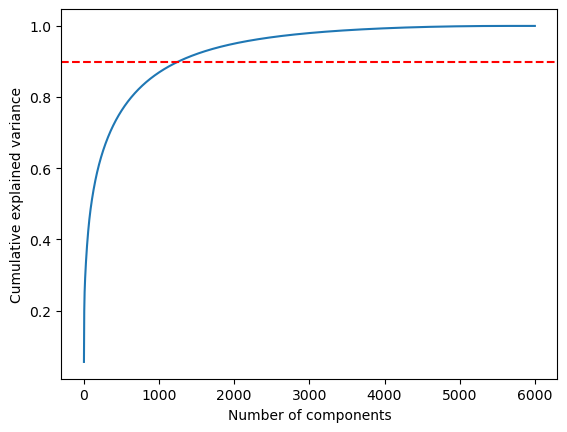

In [62]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

In [63]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.70) + 1
print(f"Number of components explaining 70% variance: {n_components}")

Number of components explaining 70% variance: 347


#### Train

In [18]:
pca = PCA(n_components=300)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [123]:
lr_final = LogisticRegression(
    penalty="l2",
    solver="saga",
    C=10, 
    class_weight="balanced",           
    max_iter=2000,
    n_jobs=-1,
    random_state=42
)

lr_final.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [ ]:
with open("02_models/trained_models/lr_baseline.pkl", "wb") as f:
    pickle.dump(lr_final, f)

#### Test

In [19]:
X_B_scaled = scaler.transform(dataB)
X_B_pca = pca.transform(X_B_scaled)

X_C_scaled = scaler.transform(dataC)
X_C_pca = pca.transform(X_C_scaled)

X_D_scaled = scaler.transform(dataD)
X_D_pca = pca.transform(X_D_scaled)

In [133]:
metricsA = metrics_report(X_test_pca, y_test, lr_final, "DRIAMS-A")
metricsB = metrics_report(X_B_pca, labelB, lr_final, "DRIAMS-B")
metricsC = metrics_report(X_C_pca, labelC, lr_final, "DRIAMS-C")
metricsD = metrics_report(X_D_pca, labelD, lr_final, "DRIAMS-D")

Printing metrics for Domain: DRIAMS-A
Balanced Accuracy: 0.9990803313022515
F1 Macro: 0.9989697375996948
Recall Macro: 0.9990803313022515
Specificity Macro: 0.9998224006330564


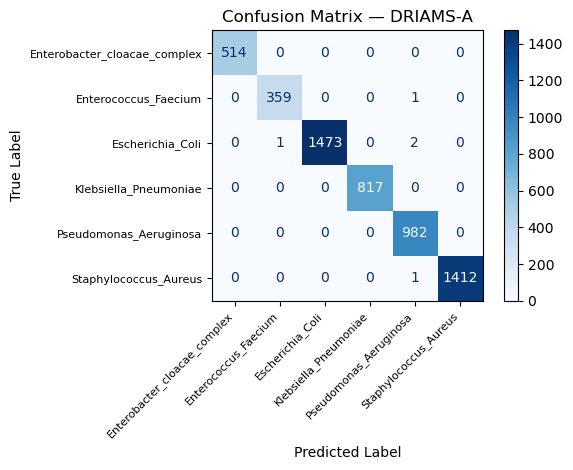

In [134]:
print_metrics(metricsA)

Printing metrics for Domain: DRIAMS-B
Balanced Accuracy: 0.9974865359996468
F1 Macro: 0.9982006886393869
Recall Macro: 0.9974865359996468
Specificity Macro: 0.9997618428924028


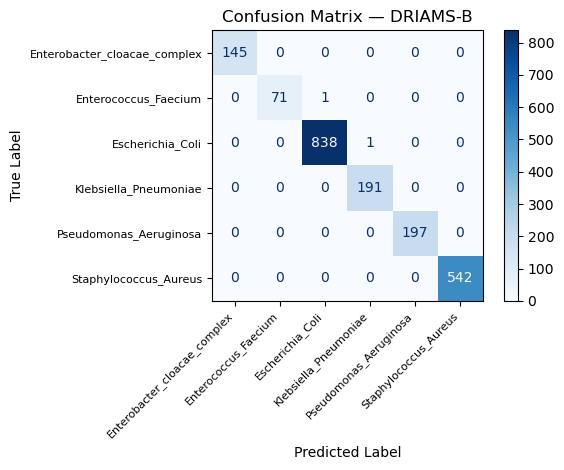

In [135]:
print_metrics(metricsB)

Printing metrics for Domain: DRIAMS-C
Balanced Accuracy: 0.9955168133996821
F1 Macro: 0.9961684115674462
Recall Macro: 0.9955168133996821
Specificity Macro: 0.9994729970026532


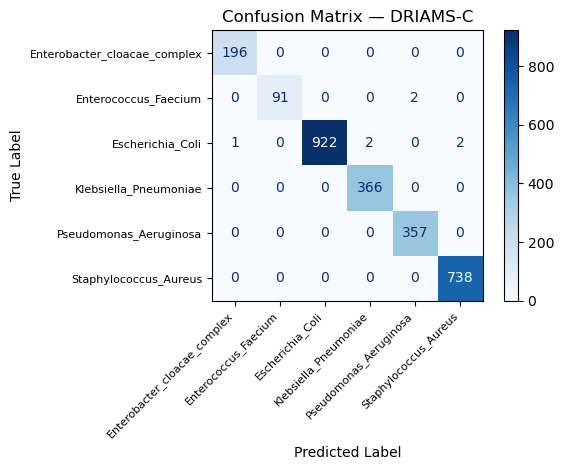

In [136]:
print_metrics(metricsC)

Printing metrics for Domain: DRIAMS-D
Balanced Accuracy: 0.9151796570545762
F1 Macro: 0.850404649750799
Recall Macro: 0.9151796570545762
Specificity Macro: 0.9806583459954643


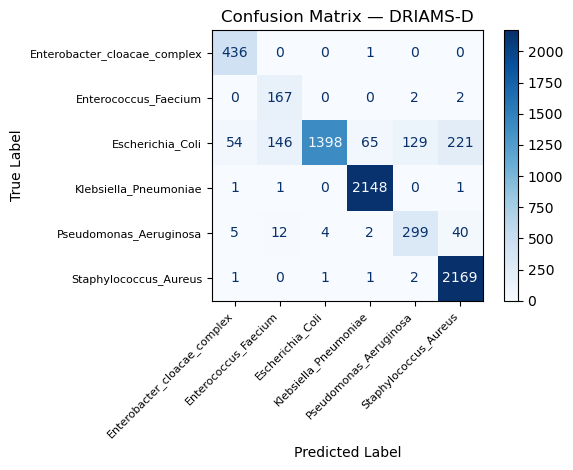

In [137]:
print_metrics(metricsD)

### RF

#### Train

In [145]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
)

rf_final.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [146]:
with open("02_models/trained_models/rf_baseline.pkl", "wb") as f:
    pickle.dump(rf_final, f)

#### Test

In [147]:
metricsA = metrics_report(X_test, y_test, rf_final, "DRIAMS-A")
metricsB = metrics_report(dataB, labelB, rf_final, "DRIAMS-B")
metricsC = metrics_report(dataC, labelC, rf_final, "DRIAMS-C")
metricsD = metrics_report(dataD, labelD, rf_final, "DRIAMS-D")

Printing metrics for Domain: DRIAMS-A
Balanced Accuracy: 0.9978885685962666
F1 Macro: 0.998331275981919
Recall Macro: 0.9978885685962666
Specificity Macro: 0.9996969458346716


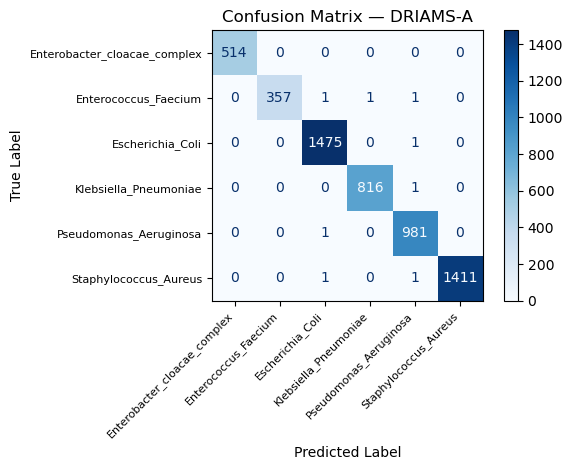

In [148]:
print_metrics(metricsA)

Printing metrics for Domain: DRIAMS-B
Balanced Accuracy: 1.0
F1 Macro: 1.0
Recall Macro: 1.0
Specificity Macro: 1.0


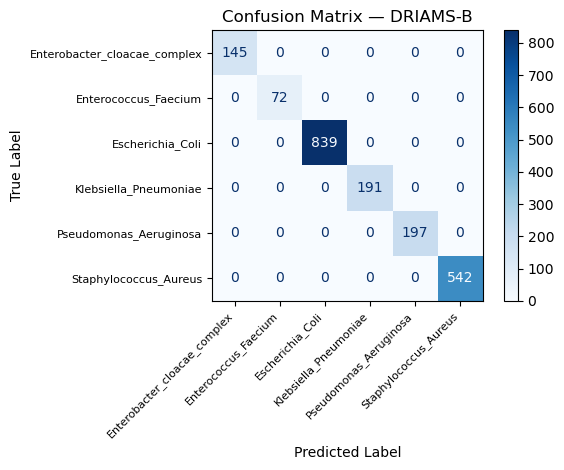

In [149]:
print_metrics(metricsB)

Printing metrics for Domain: DRIAMS-C
Balanced Accuracy: 0.9968181708428231
F1 Macro: 0.9974301575321514
Recall Macro: 0.9968181708428231
Specificity Macro: 0.9995938356916106


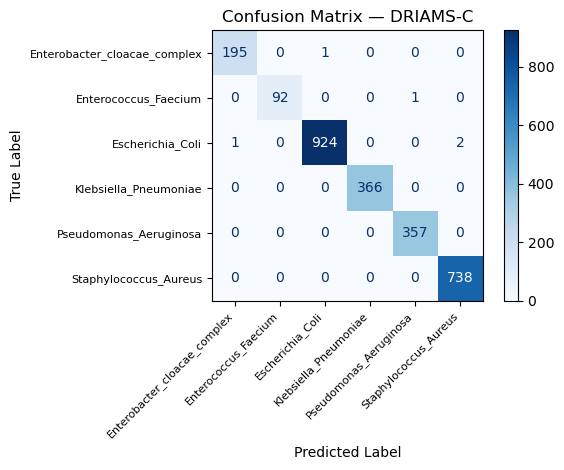

In [150]:
print_metrics(metricsC)

Printing metrics for Domain: DRIAMS-D
Balanced Accuracy: 0.9169103870281164
F1 Macro: 0.8877243010105352
Recall Macro: 0.9169103870281164
Specificity Macro: 0.9796940724742479


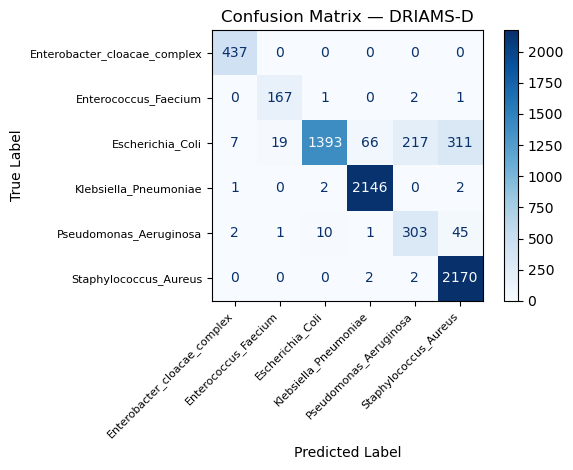

In [151]:
print_metrics(metricsD)

### SVM-Linear

#### Train

In [14]:
svm_final = LinearSVC(
    class_weight='balanced', 
    C=0.001)

svm_final.fit(X_train_scaled, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.001
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [15]:
with open("02_models/trained_models/svm_baseline.pkl", "wb") as f:
    pickle.dump(svm_final, f)

#### Test

In [20]:
metricsA = metrics_report(X_test_scaled, y_test, svm_final, "DRIAMS-A")
metricsB = metrics_report(X_B_scaled, labelB, svm_final, "DRIAMS-B")
metricsC = metrics_report(X_C_scaled, labelC, svm_final, "DRIAMS-C")
metricsD = metrics_report(X_D_scaled, labelD, svm_final, "DRIAMS-D")

Printing metrics for Domain: DRIAMS-A
Balanced Accuracy: 0.9976356069388904
F1 Macro: 0.9970614842390342
Recall Macro: 0.9976356069388904
Specificity Macro: 0.999546231234802


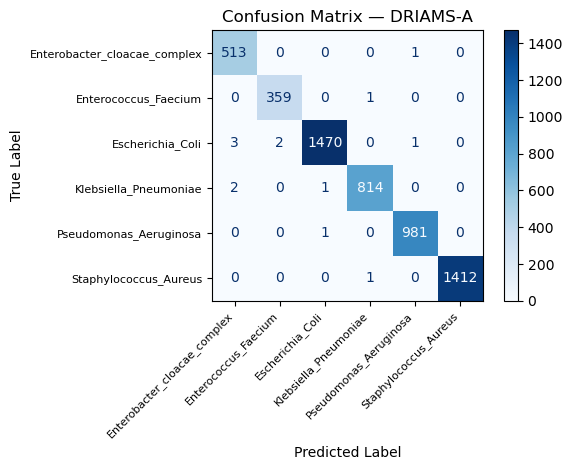

In [21]:
print_metrics(metricsA)

Printing metrics for Domain: DRIAMS-B
Balanced Accuracy: 0.9998013508144616
F1 Macro: 0.9994654551701124
Recall Macro: 0.9998013508144616
Specificity Macro: 0.9999071494893222


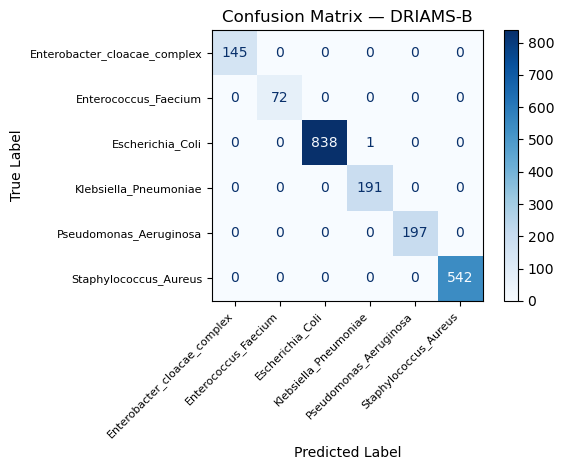

In [22]:
print_metrics(metricsB)

Printing metrics for Domain: DRIAMS-C
Balanced Accuracy: 0.9973089280950228
F1 Macro: 0.9973115539845745
Recall Macro: 0.9973089280950228
Specificity Macro: 0.9995448360831131


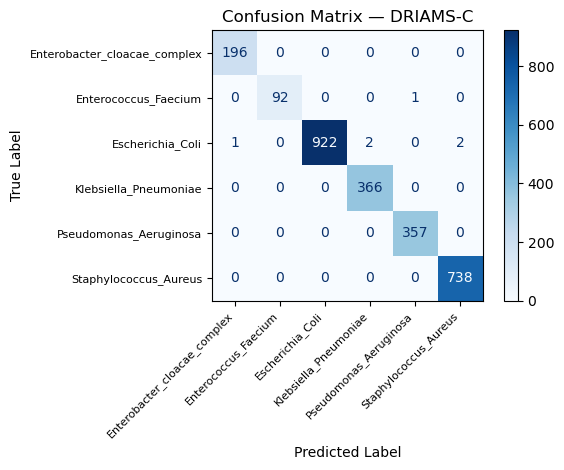

In [23]:
print_metrics(metricsC)

Printing metrics for Domain: DRIAMS-D
Balanced Accuracy: 0.9164555957495417
F1 Macro: 0.8618503358805055
Recall Macro: 0.9164555957495417
Specificity Macro: 0.9823006574831646


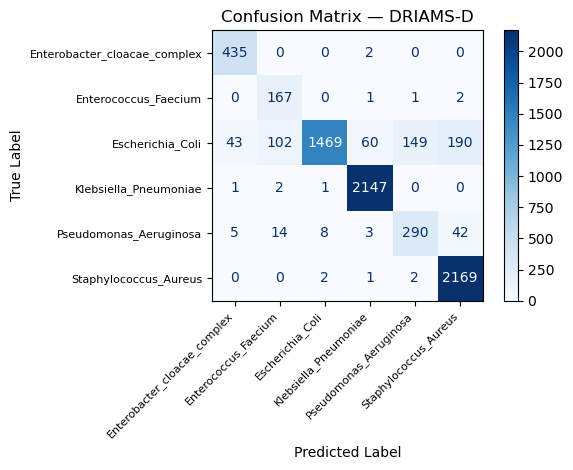

In [24]:
print_metrics(metricsD)